# Thalamocortical Model Scaling Analysis

This notebook analyzes the scaling relationship between the input relay (LGN, $N$) and the cortical expansion (V1, $K$). It investigates the optimal expansion factor across margins and connectivity paradigms (Trained vs. Probabilistic).

In [1]:
import os
import glob
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

In [2]:
def load_results(margin_val, is_trained=True):
    prefix = "unconstrained" if is_trained else "probabilistic"
    res_dir = f"results_{prefix}_margin{margin_val}"
    files = glob.glob(os.path.join(res_dir, "res_LGN*_V1*.pkl"))
    
    data_list = []
    for f in files:
        basename = os.path.basename(f)
        parts = basename.split('_')
        try:
            lgn = int(parts[1][3:])
            v1 = int(parts[2][2:].split('.')[0])
            
            with open(f, 'rb') as fr:
                res = pickle.load(fr)
                # Metrics: Loss, Violations, Gini
                loss = float(res.get('test_loss', np.nan))
                viol = float(res.get('test_viol', np.nan)) * 100 # Percentage
                gini = float(res.get('v1_gini', np.nan))
                
                data_list.append({
                    'margin': margin_val,
                    'type': 'Trained' if is_trained else 'Probabilistic', 
                    'N': lgn,
                    'K': v1, 
                    'Loss': loss, 
                    'Violations': viol, 
                    'Gini': gini
                })
        except:
            continue
    return pd.DataFrame(data_list)

df_list = []
for m in [0, 3]:
    df_list.append(load_results(m, is_trained=True))
    df_list.append(load_results(m, is_trained=False))

df = pd.concat(df_list, ignore_index=True)
df = df.sort_values(['margin', 'type', 'N', 'K'])
print(f"Experiment dataset size: {len(df)}")

Experiment dataset size: 240


## 1. Performance Landscapes (K-Scaling)

For each (margin, LGN size, metric) triple, we visualize the cortical expansion curve ($K$). 
The 'best' performing model for each paradigm (Trained/Probabilistic) is marked with an 'X'.

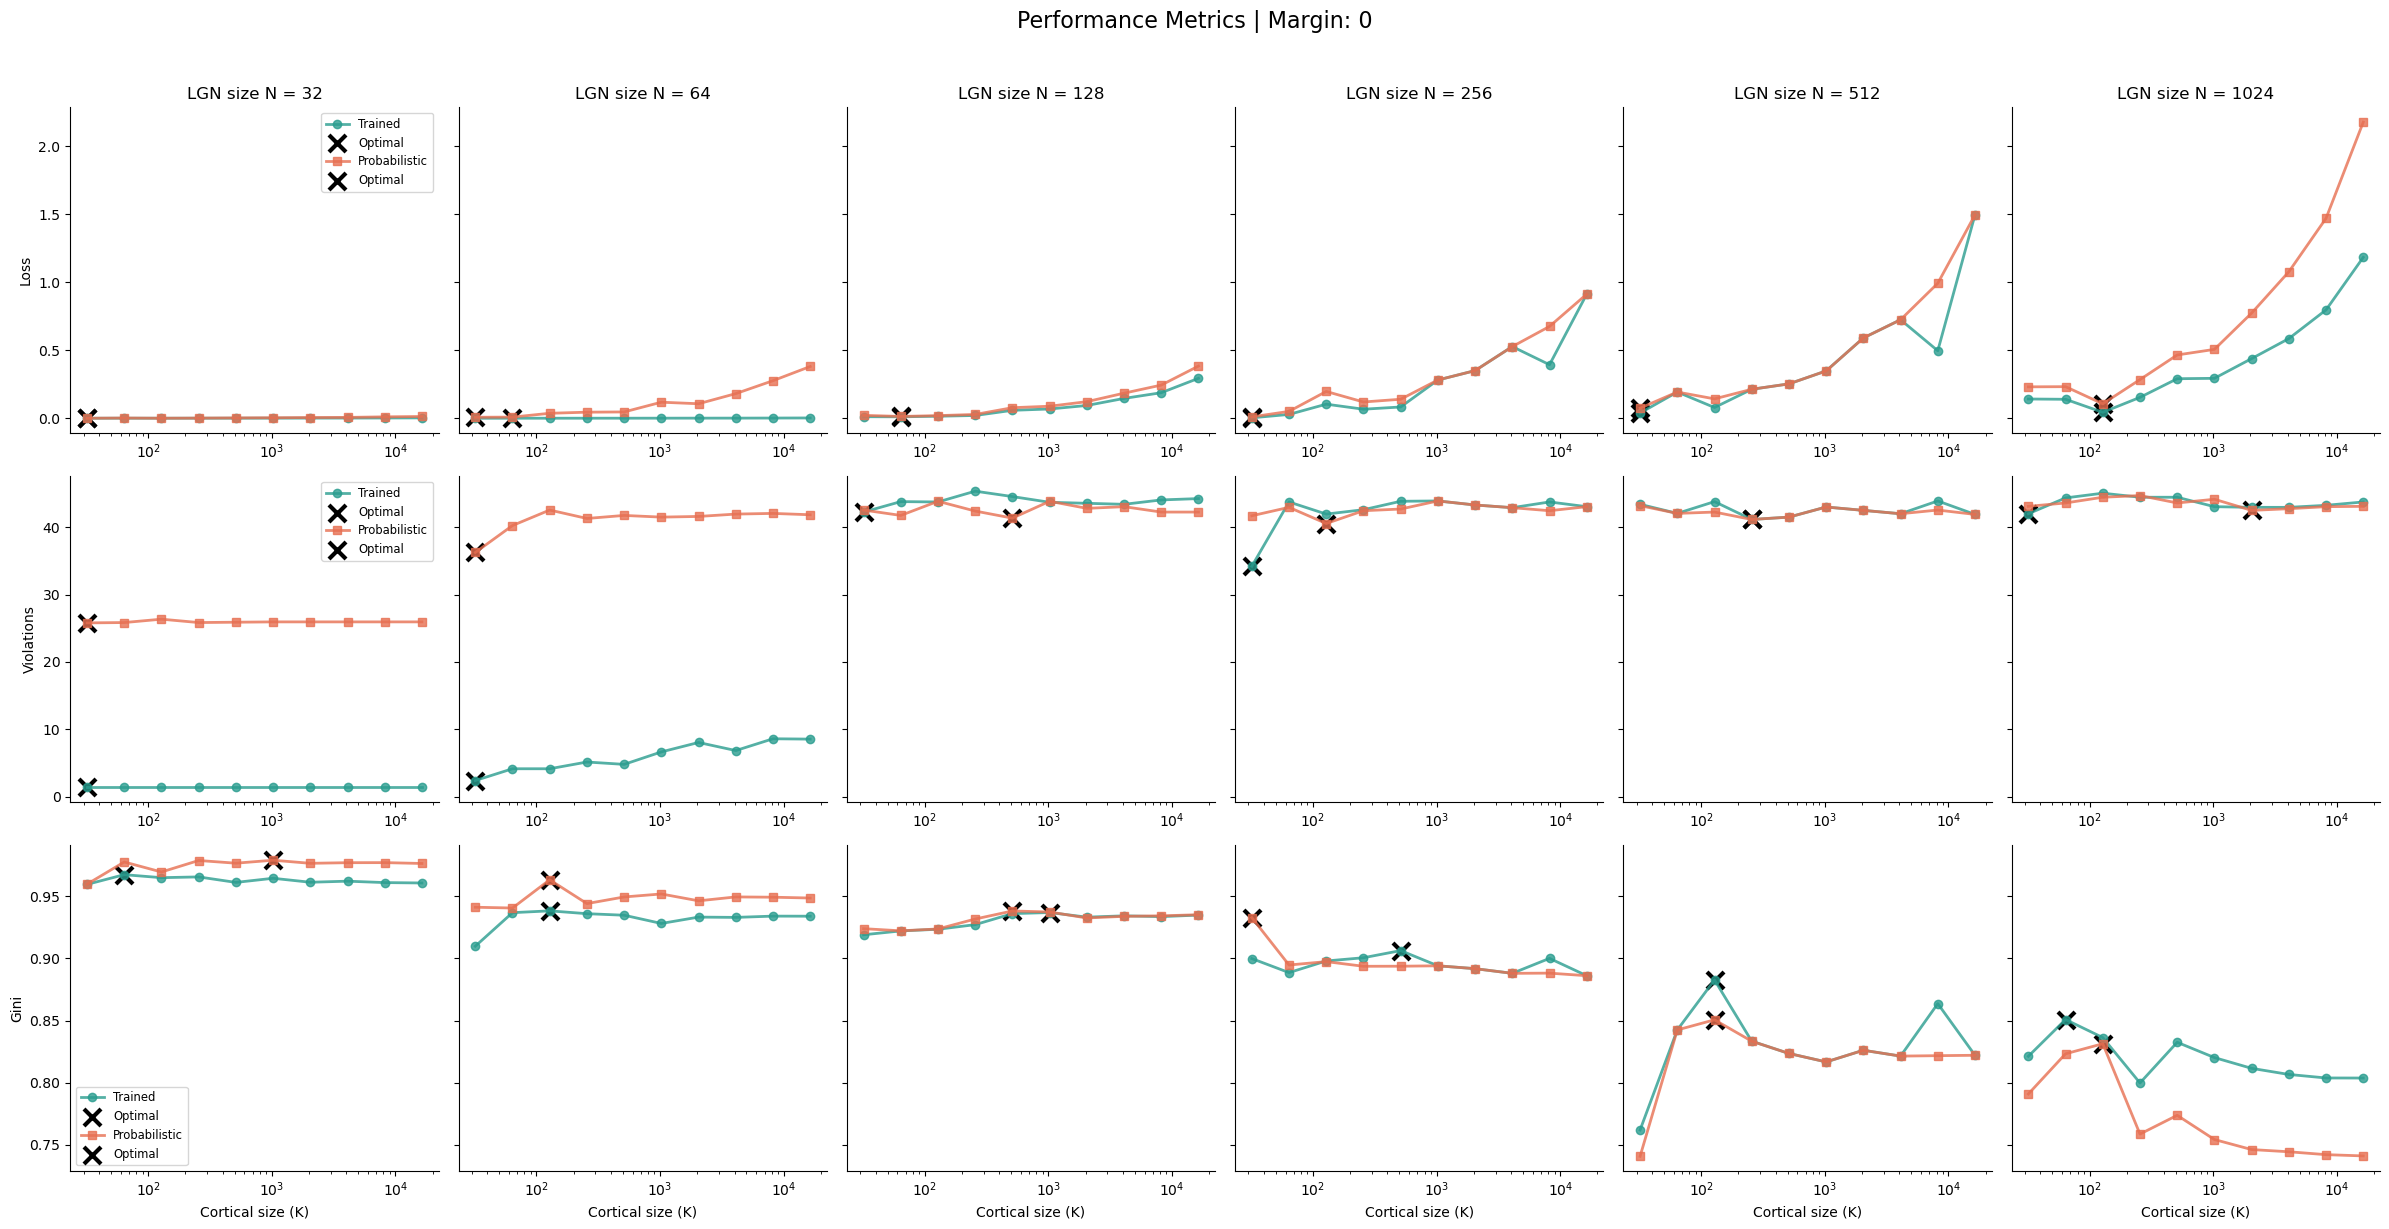

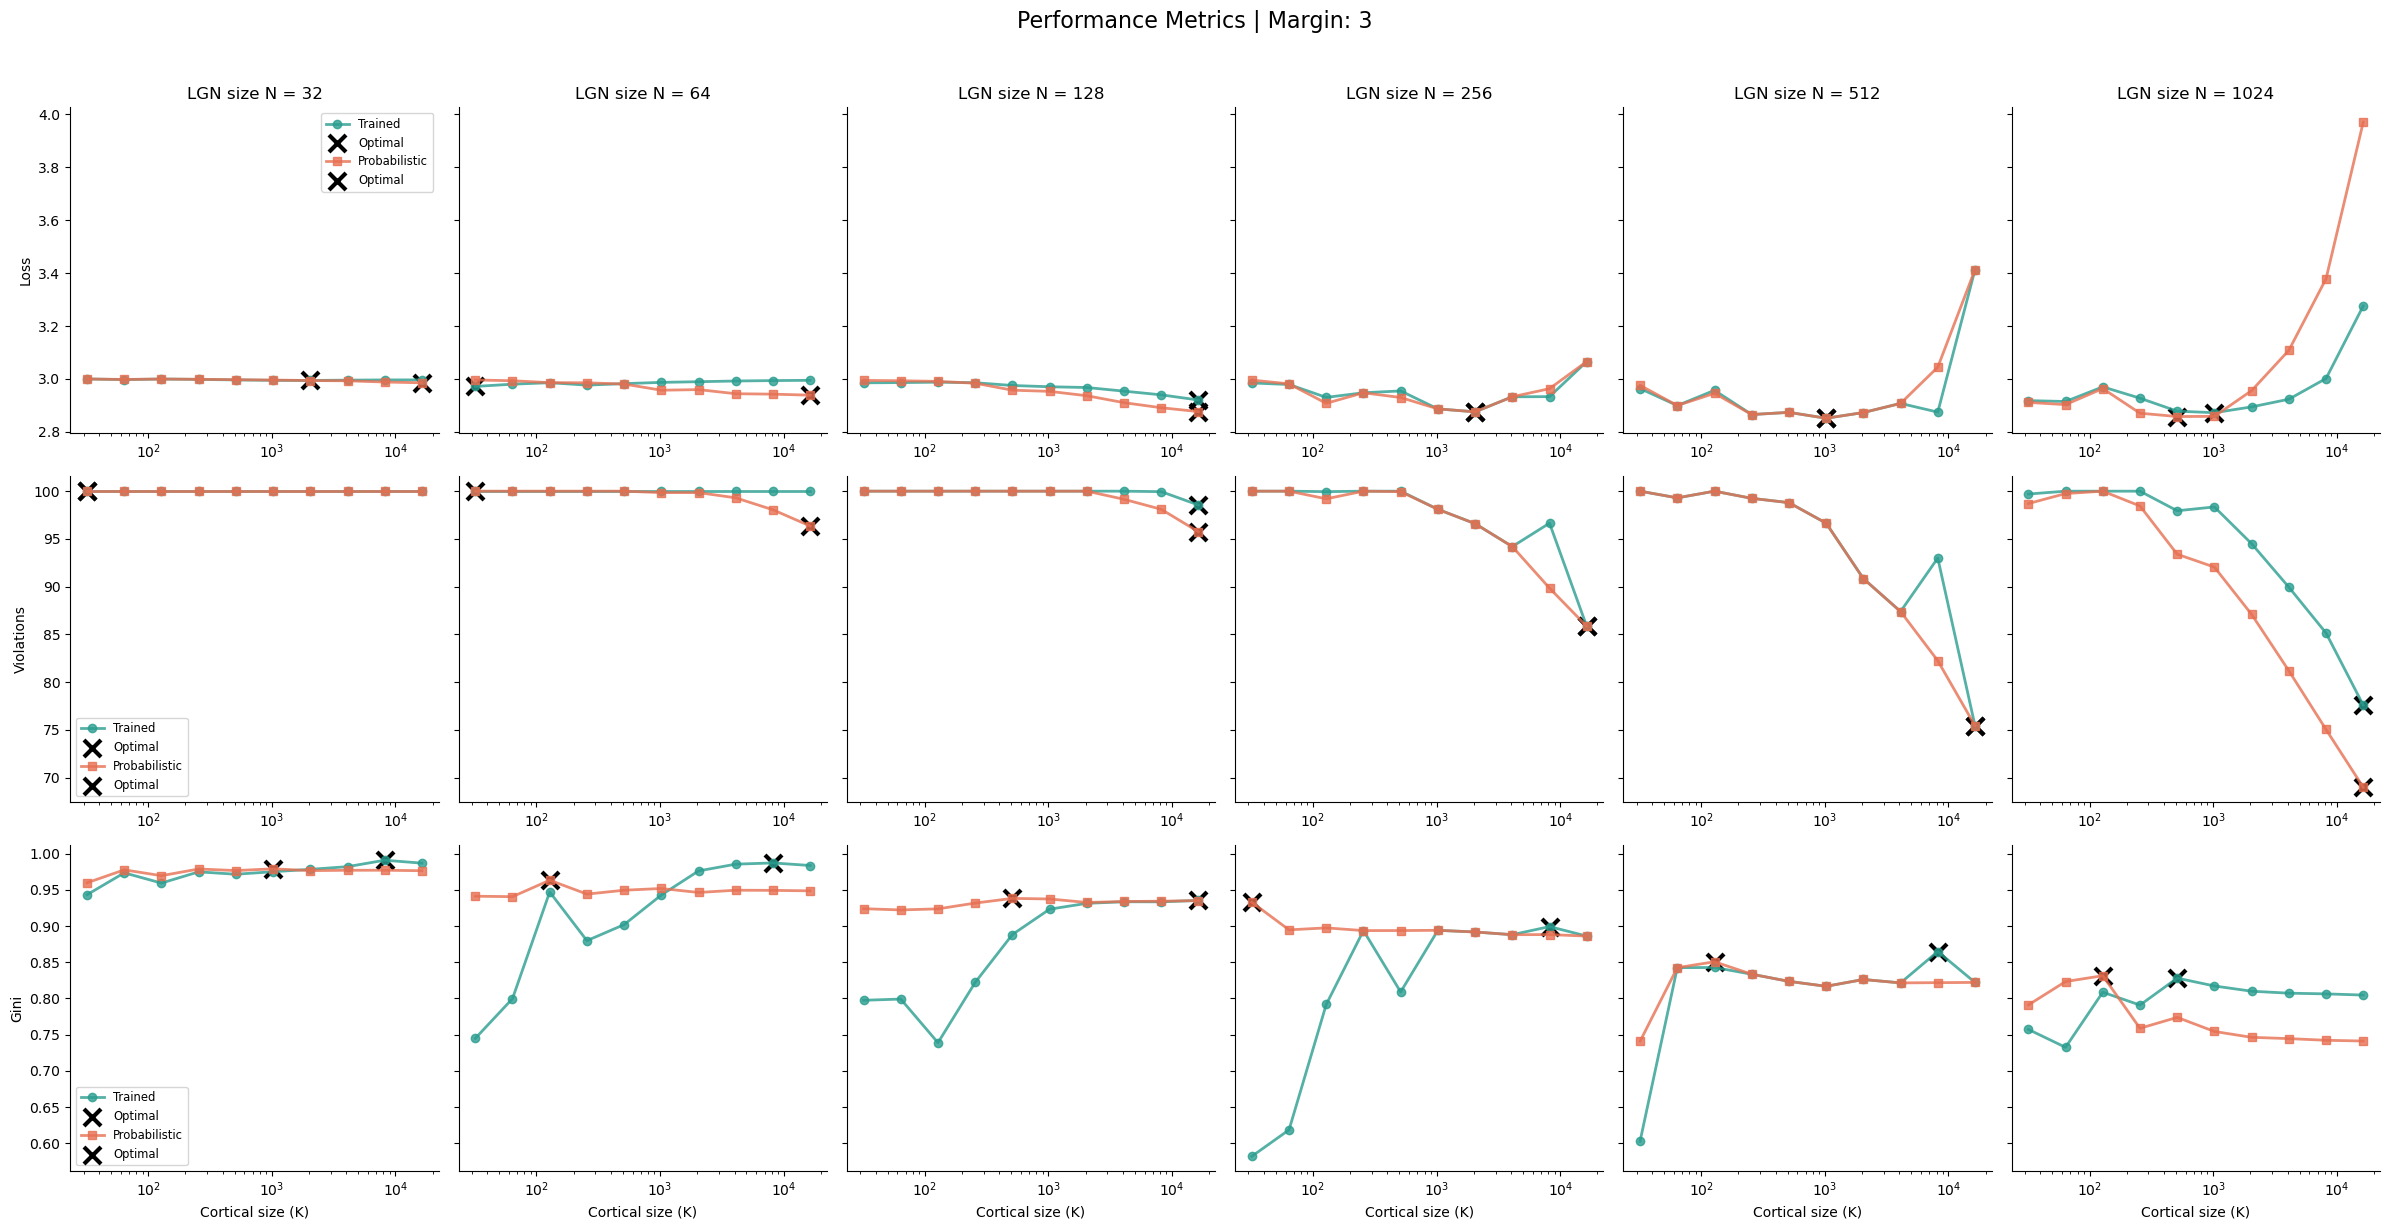

In [4]:
margins = sorted(df['margin'].unique())
lgn_sizes = sorted(df['N'].unique())
metrics = ['Loss', 'Violations', 'Gini']
is_min_metric = {'Loss': True, 'Violations': True, 'Gini': False}  # True if metric should be minimized

for m in margins:

    # Create figure: 3 rows (metrics) x up to 6 cols (LGN sizes)
    n_cols = min(len(lgn_sizes), 6)
    fig, axes = plt.subplots(len(metrics), n_cols, figsize=(4*n_cols, 4*len(metrics)), sharey='row')
    fig.suptitle(f"Performance Metrics | Margin: {m}", fontsize=16, y=1.02)

    for j, metric in enumerate(metrics):

        # axes[j] is either 1D or 2D depending on n_cols; ensure it’s iterable
        axes_row = axes[j] if len(metrics) > 1 else axes
        if n_cols == 1:
            axes_row = [axes_row]

        for i, n in enumerate(lgn_sizes[:n_cols]):
            ax = axes_row[i]

            for t in ['Trained', 'Probabilistic']:
                sub = df[(df['margin'] == m) & (df['N'] == n) & (df['type'] == t)]
                if sub.empty: 
                    continue

                color = '#2A9D8F' if t == 'Trained' else '#E76F51'
                marker = 'o' if t == 'Trained' else 's'

                # Plot curve
                ax.plot(sub['K'], sub[metric], marker=marker, label=t, color=color, linewidth=2, alpha=0.8)

                # Mark best performing model
                if is_min_metric[metric]:
                    best_idx = sub[metric].idxmin()
                else:
                    best_idx = sub[metric].idxmax()
                best_model = sub.loc[best_idx]
                ax.scatter(
                    best_model['K'], best_model[metric],
                    marker='x', s=150, color='black',
                    linewidths=3, label=f"Optimal"
                )

            ax.set_xscale('log')

            # set titles only for outer plots
            if j == 0:
                ax.set_title(f"LGN size N = {n}", fontsize=12)
            if j == 2:
                ax.set_xlabel("Cortical size (K)")
            if i == 0:
                ax.set_ylabel(metric)
                ax.legend(fontsize='small')

    plt.tight_layout()
    plt.show()

## 2. Optimal Architecture Scaling

We investigate the relationship between input size ($N$) and optimal cortical size ($K$) across each metric. 
This determines if the network favors a specific expansion ratio (K/N) for peak performance.

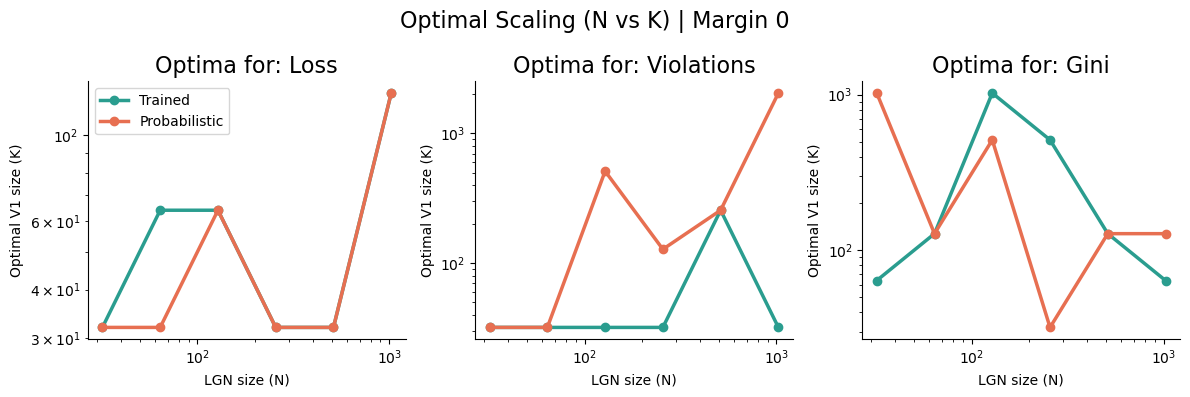

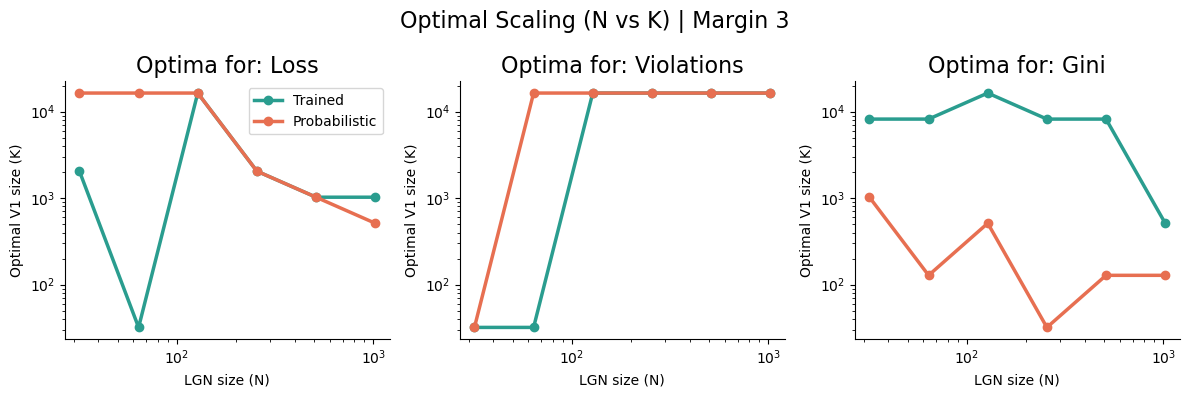

In [6]:
opt_results = []
for m in margins:
    for t in ['Trained', 'Probabilistic']:
        for n in lgn_sizes:
            sub = df[(df['margin'] == m) & (df['type'] == t) & (df['N'] == n)]
            if sub.empty: continue
            
            for metric in metrics:
                if is_min_metric[metric]:
                    idx = sub[metric].idxmin()
                else:
                    idx = sub[metric].idxmax()
                
                res = sub.loc[idx]
                opt_results.append({
                    'margin': m, 'type': t, 'N': n, 'metric': metric, 
                    'opt_K': res['K'], 'opt_ratio': res['K']/n
                })

df_opt = pd.DataFrame(opt_results)

for m in margins:
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    fig.suptitle(f"Optimal Scaling (N vs K) | Margin {m}", fontsize=16)
    
    for i, metric in enumerate(metrics):
        ax = axes[i]
        
        for t in ['Trained', 'Probabilistic']:
            sub_opt = df_opt[(df_opt['margin'] == m) & (df_opt['type'] == t) & (df_opt['metric'] == metric)]
            color = '#2A9D8F' if t == 'Trained' else '#E76F51'
            ax.plot(sub_opt['N'], sub_opt['opt_K'], 'o-', label=t, color=color, linewidth=2.5)
            
        ax.set_title(f"Optima for: {metric}", fontsize=16)
        #ax.set_xscale('log'); ax.set_yscale('log')
        ax.set_xlabel("LGN size (N)")
        ax.set_ylabel("Optimal V1 size (K)")
        ax.set_xscale("log")
        ax.set_yscale("log")
        if i == 0: ax.legend()
        
    plt.tight_layout()
    plt.show()

### 2.1 Optimal Expansion Ratio (K/N) vs N

Visualizing the power-law relationship of the expansion factor itself.

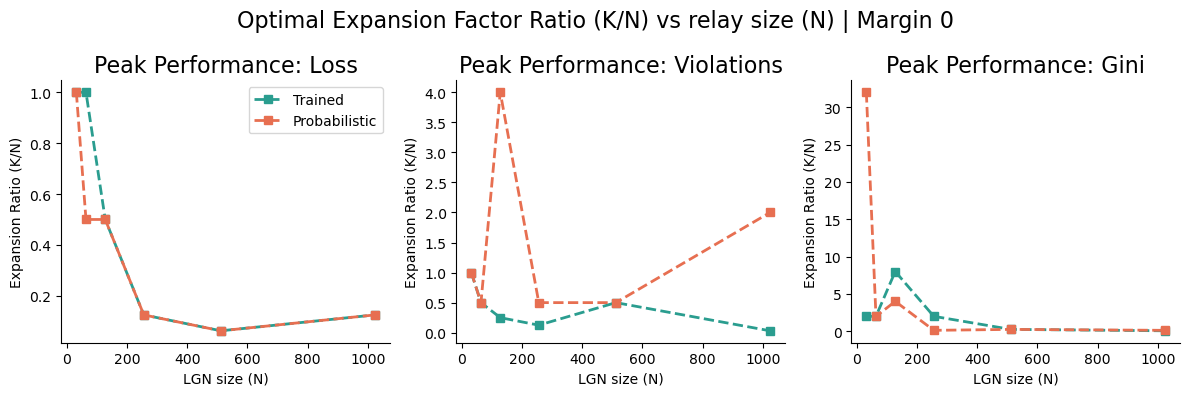

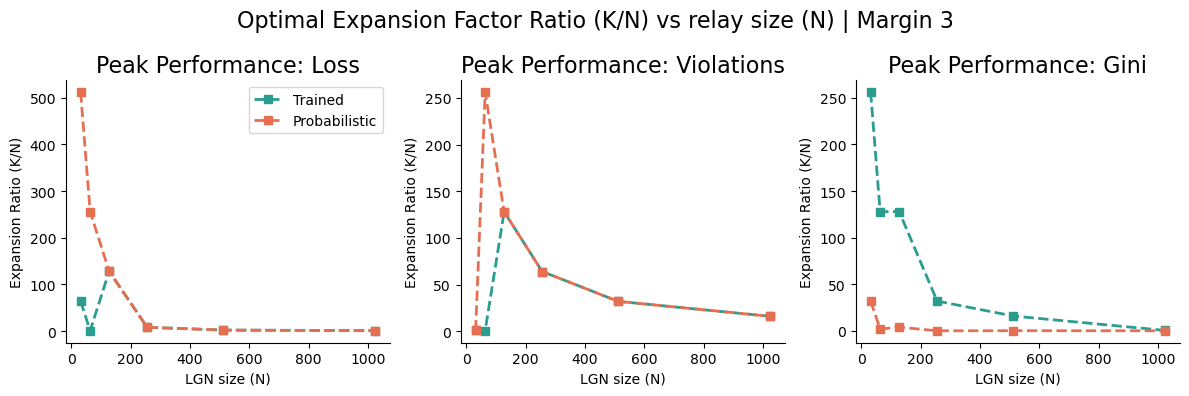

In [17]:
for m in margins:
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    fig.suptitle(f"Optimal Expansion Factor Ratio (K/N) vs relay size (N) | Margin {m}", fontsize=16)
    
    for i, metric in enumerate(metrics):
        ax = axes[i]
        
        for t in ['Trained', 'Probabilistic']:
            sub_opt = df_opt[(df_opt['margin'] == m) & (df_opt['type'] == t) & (df_opt['metric'] == metric)]
            color = '#2A9D8F' if t == 'Trained' else '#E76F51'
            ax.plot(sub_opt['N'], sub_opt['opt_ratio'], 's--', label=t, color=color, linewidth=2)
            
        ax.set_title(f"Peak Performance: {metric}", fontsize=16)
        #ax.set_xscale('log'); ax.set_yscale('log')
        ax.set_xlabel("LGN size (N)")
        ax.set_ylabel("Expansion Ratio (K/N)")
        if i == 0: ax.legend()
        
    plt.tight_layout()
    plt.show()

Hmm, this is a bit intersting. It seems that when the LGN is large, smaller V1 layers are preferred, but when LGN is smaller, it prefers larger V1. this is a bit perplexing. We were hoping that as LGN size increases, V1 size increases with an exponential relationship.

### 3. Computing a combined metric
Combine the metrics together according to a formula to see if the combined metric produces a more reliable readout.

In [33]:
def combined_score(df_sub, metrics=['Loss','Violations','Gini']):

    df_norm = df_sub.copy()

    for metric in metrics:
        min_val = df_sub[metric].min()
        max_val = df_sub[metric].max()

        if metric == 'Gini':  # gini is already 0-1, so we can leave it as such
            df_norm[metric + '_norm'] = df_sub[metric].values
        else:  # maximize
            df_norm[metric + '_norm'] = 1 - (df_sub[metric] - min_val)/(max_val - min_val + 1e-12)

    # simple average of normalized metrics
    df_norm['combined_score'] = (np.array([0.1, 0.3, 0.6]) * df_norm[[m + '_norm' for m in metrics]].values).sum(axis=1)
    return df_norm

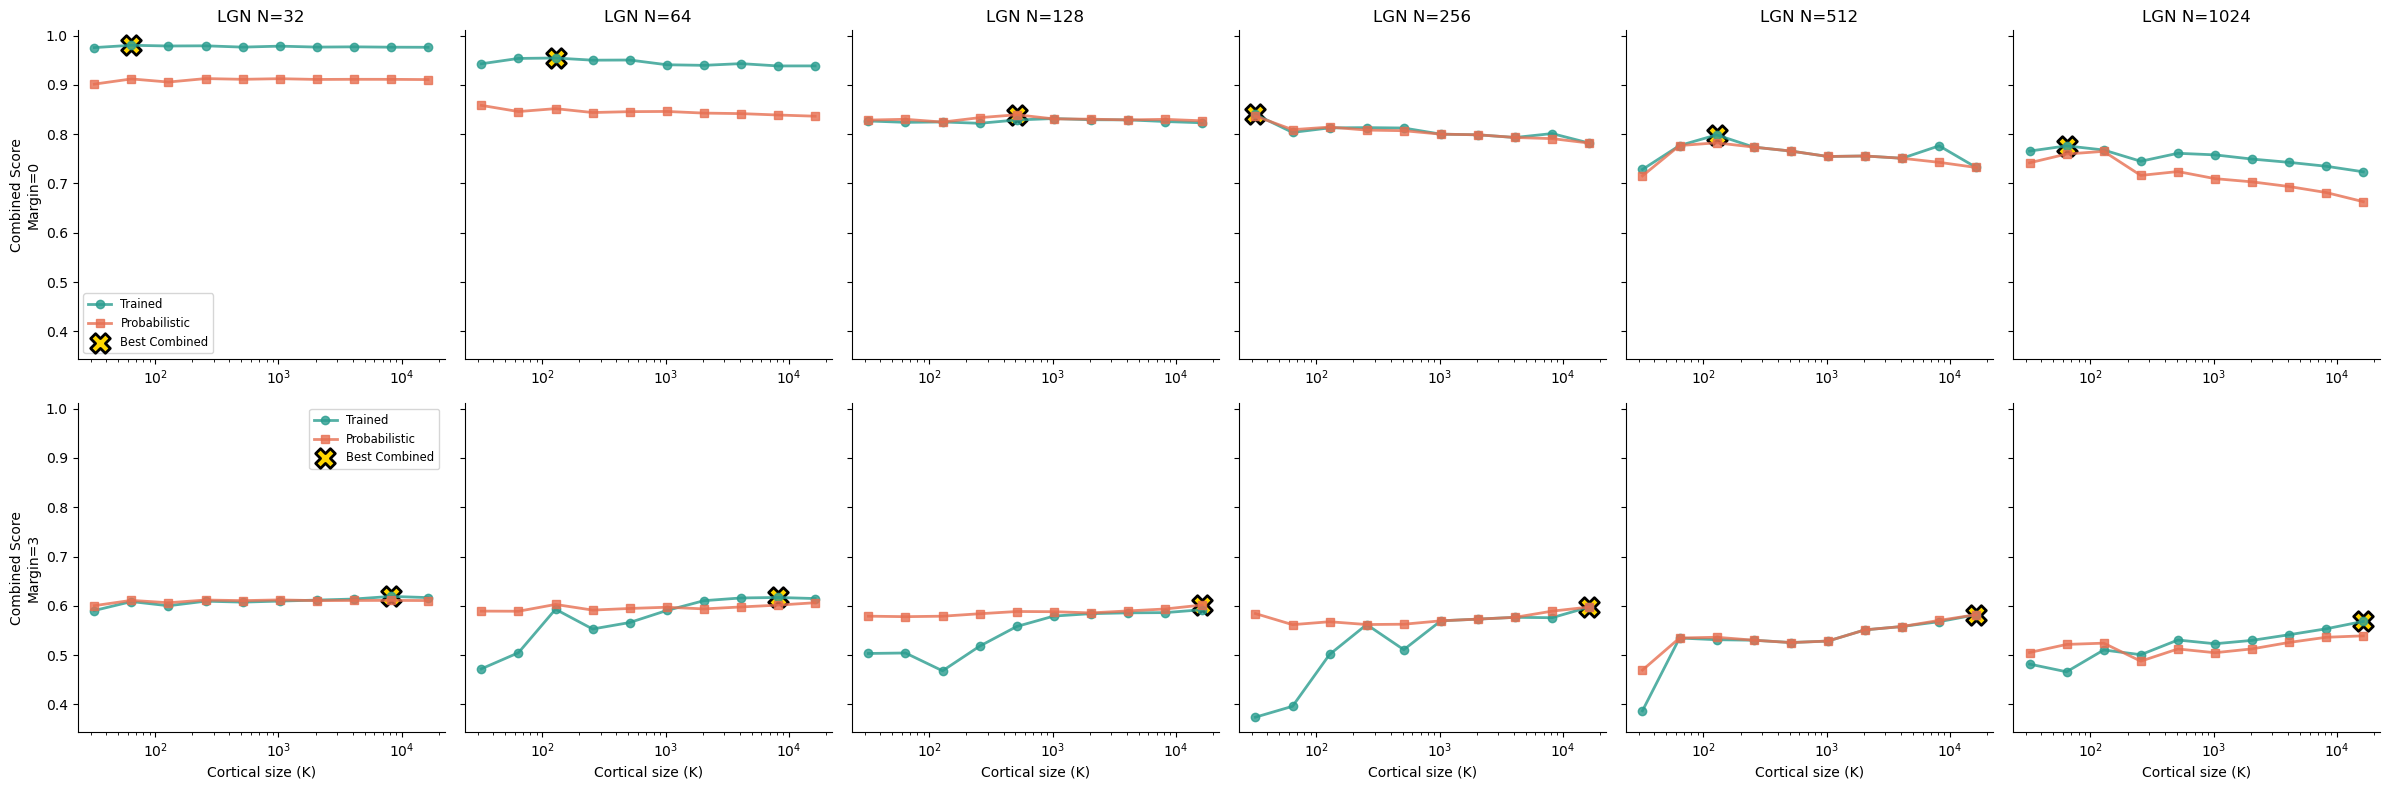

In [34]:
# --- Step 1: Compute combined scores for all models once ---
df_scored = combined_score(df)  # df contains all margins, LGN sizes, V1 dims, and types

# --- Step 2: Plotting per margin ---
lgn_sizes = sorted(df_scored['N'].unique())
margins = sorted(df_scored['margin'].unique())
max_cols = 6  # max LGN per row

fig, axes = plt.subplots(len(margins), max_cols, figsize=(4*max_cols, 4*len(margins)), sharey=True)

# Ensure axes is iterable
if len(margins) == 1:
    axes = [axes]

for row_idx, m in enumerate(margins):
    axes_row = axes[row_idx]

    for col_idx, n in enumerate(lgn_sizes[:max_cols]):
        ax = axes_row[col_idx]

        # Subset for this margin and LGN size
        df_sub = df_scored[(df_scored['margin'] == m) & (df_scored['N'] == n)]
        if df_sub.empty:
            ax.set_visible(False)
            continue

        # Plot Trained vs Probabilistic curves
        for t, color, marker in zip(['Trained', 'Probabilistic'], ['#2A9D8F', '#E76F51'], ['o','s']):
            df_t = df_sub[df_sub['type'] == t]
            if df_t.empty:
                continue
            ax.plot(df_t['K'], df_t['combined_score'], label=t, color=color, marker=marker, linewidth=2, alpha=0.8)

        # Mark the best model (highest combined score) across both types
        best_idx = df_sub['combined_score'].idxmax()
        best_model = df_sub.loc[best_idx]
        ax.scatter(
            best_model['K'], best_model['combined_score'],
            marker='X', s=200, color='gold', edgecolors='black', linewidths=2,
            label='Best Combined' if col_idx == 0 else "_nolegend_"
        )

        ax.set_xscale('log')
        if row_idx == 1:
            ax.set_xlabel('Cortical size (K)')
        if col_idx == 0:
            ax.set_ylabel(f'Combined Score\nMargin={m}')
        if row_idx == 0:
            ax.set_title(f'LGN N={n}')
        if col_idx == 0:
            ax.legend(fontsize='small')

plt.tight_layout()
plt.show()

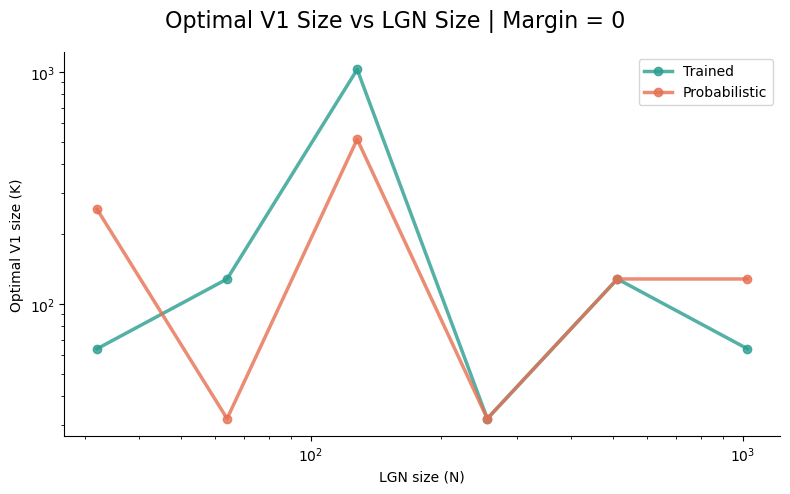

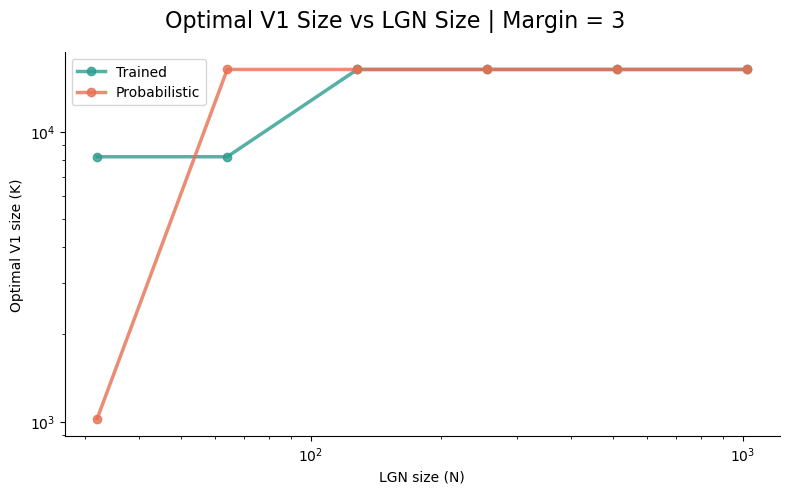

In [38]:
# --- Step 1: compute best models per combined score ---
opt_results = []

for m in margins:
    for t in ['Trained', 'Probabilistic']:
        for n in lgn_sizes:
            sub = df_scored[(df_scored['margin'] == m) & 
                            (df_scored['type'] == t) & 
                            (df_scored['N'] == n)]
            if sub.empty:
                continue

            # Select the best model based on combined score
            best_idx = sub['combined_score'].idxmax()
            best_model = sub.loc[best_idx]

            opt_results.append({
                'margin': m,
                'type': t,
                'N': n,
                'opt_K': best_model['K'],
                'opt_ratio': best_model['K'] / n,
                'combined_score': best_model['combined_score']
            })

df_opt = pd.DataFrame(opt_results)

# --- Step 2: Plot LGN size vs optimal V1 size for each margin ---
for m in margins:
    fig, ax = plt.subplots(figsize=(8,5))
    fig.suptitle(f"Optimal V1 Size vs LGN Size | Margin = {m}", fontsize=16)

    for t, color in zip(['Trained','Probabilistic'], ['#2A9D8F','#E76F51']):
        sub_opt = df_opt[(df_opt['margin'] == m) & (df_opt['type'] == t)]
        if sub_opt.empty:
            continue
        ax.plot(sub_opt['N'], sub_opt['opt_K'], 'o-', label=t, color=color, linewidth=2.5, alpha=0.8)

    ax.set_xlabel("LGN size (N)")
    ax.set_ylabel("Optimal V1 size (K)")
    ax.legend()
    ax.grid(False)

    ax.set_xscale("log")
    ax.set_yscale("log")

    plt.tight_layout()
    plt.show()